<a href="https://colab.research.google.com/github/Master-GB/waste-classification/blob/feature%2Fmodel-CustomCNN/CustomCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell 1: Kaggle Setup and Dataset Download

In [1]:
# Install required libraries
!pip install -q kagglehub scikit-learn seaborn matplotlib torchsummary

import os
import shutil
import kagglehub

# Download directly using the Kaggle dataset handle/URL path
# URL: https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2
download_path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")
print(f"Dataset downloaded to cache at: {download_path}")

# Symlink or move the files to a consistent local folder for the rest of the notebook
local_data_dir = "./garbage_data"
if os.path.exists(local_data_dir):
    shutil.rmtree(local_data_dir)

# Create a symlink to avoid taking up extra disk space in Colab
os.symlink(download_path, local_data_dir)
print(f"Dataset ready at: {local_data_dir}")

100%|██████████| 1.07G/1.07G [00:10<00:00, 107MB/s]

Extracting files...


Dataset downloaded to cache at: /root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12
Dataset ready at: ./garbage_data


Cell 2: Imports and Global Reproducibility Configuration

In [2]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import label_binarize

# Set fixed seed for reproducibility across runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Cell 3: Manifest Creation (Stratified 70/15/15 Split)

In [3]:
# Fixed class mapping matching the project definition
CLASS_MAPPING = {
    'battery': 0,
    'biological': 1,
    'cardboard': 2,
    'clothes': 3,
    'glass': 4,
    'metal': 5,
    'paper': 6,
    'plastic': 7,
    'shoes': 8,
    'trash': 9
}

# Locate dataset root folder
base_data_dir = "./garbage_data"
# Find subdirectory containing class folders if nested
subdirs = [os.path.join(base_data_dir, d) for d in os.listdir(base_data_dir) if os.path.isdir(os.path.join(base_data_dir, d))]
data_dir = base_data_dir
for sd in subdirs:
    if any(c in os.listdir(sd) for c in CLASS_MAPPING.keys()):
        data_dir = sd
        break

# Gather all image paths and labels
records = []
for class_name, class_idx in CLASS_MAPPING.items():
    class_folder = os.path.join(data_dir, class_name)
    if os.path.exists(class_folder):
        for fname in os.listdir(class_folder):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                records.append({
                    'filepath': os.path.join(class_folder, fname),
                    'label': class_idx,
                    'class_name': class_name
                })

df = pd.DataFrame(records)
print(f"Total verified images: {len(df)}")

# Stratified 70:15:15 split
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label'])

os.makedirs("./manifests", exist_ok=True)
train_df.to_csv("./manifests/train.csv", index=False)
val_df.to_csv("./manifests/val.csv", index=False)
test_df.to_csv("./manifests/test.csv", index=False)

print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples:       {len(test_df)}")

Total verified images: 12259
Training samples:   8581
Validation samples: 1839
Test samples:       1839


Cell 4: Dataset and DataLoader Implementation

In [4]:
# Custom Dataset with RGB verification
class GarbageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'filepath']
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.loc[idx, 'label'])

        if self.transform:
            image = self.transform(image)

        return image, label

# ImageNet normalization statistics
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

# Shared training transformations with dynamic augmentation
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

# Deterministic validation and test transformations
eval_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

train_dataset = GarbageDataset(train_df, transform=train_transforms)
val_dataset = GarbageDataset(val_df, transform=eval_transforms)
test_dataset = GarbageDataset(test_df, transform=eval_transforms)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Cell 5: Custom CNN Architecture Definition
Python

In [5]:
class CustomWasteCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomWasteCNN, self).__init__()

        # Block 1: 224x224 -> 112x112
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        # Block 2: 112x112 -> 56x56
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        # Block 3: 56x56 -> 28x28
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        # Block 4: 28x28 -> 14x14
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        # Classifier
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

model = CustomWasteCNN(num_classes=10).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Custom CNN initialized. Trainable Parameters: {total_params:,}")

Custom CNN initialized. Trainable Parameters: 423,562


Cell 6: Training and Validation Loop with Checkpointing

In [6]:
EPOCHS = 25
LEARNING_RATE = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_loss = float('inf')
checkpoint_path = "best_custom_cnn.pth"

for epoch in range(EPOCHS):
    # Training Phase
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data).item()
        total += labels.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    # Validation Phase
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data).item()
            val_total += labels.size(0)

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    scheduler.step(epoch_val_loss)

    print(f"Epoch {epoch+1:02d}/{EPOCHS:02d} | "
          f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f}")

    # Save checkpoint with lowest validation loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), checkpoint_path)
        print(f" --> Checkpoint saved at epoch {epoch+1}")

Epoch 01/25 | Train Loss: 1.8843 - Train Acc: 0.3311 | Val Loss: 1.6718 - Val Acc: 0.4405
 --> Checkpoint saved at epoch 1
Epoch 02/25 | Train Loss: 1.6911 - Train Acc: 0.4026 | Val Loss: 1.5471 - Val Acc: 0.4589
 --> Checkpoint saved at epoch 2
Epoch 03/25 | Train Loss: 1.5826 - Train Acc: 0.4530 | Val Loss: 1.5800 - Val Acc: 0.4470
Epoch 04/25 | Train Loss: 1.5187 - Train Acc: 0.4664 | Val Loss: 1.4780 - Val Acc: 0.4649
 --> Checkpoint saved at epoch 4
Epoch 05/25 | Train Loss: 1.4568 - Train Acc: 0.4878 | Val Loss: 1.3264 - Val Acc: 0.5302
 --> Checkpoint saved at epoch 5
Epoch 06/25 | Train Loss: 1.4138 - Train Acc: 0.5039 | Val Loss: 1.2834 - Val Acc: 0.5481
 --> Checkpoint saved at epoch 6
Epoch 07/25 | Train Loss: 1.3756 - Train Acc: 0.5167 | Val Loss: 1.2879 - Val Acc: 0.5481
Epoch 08/25 | Train Loss: 1.3530 - Train Acc: 0.5276 | Val Loss: 1.2019 - Val Acc: 0.5840
 --> Checkpoint saved at epoch 8
Epoch 09/25 | Train Loss: 1.3142 - Train Acc: 0.5421 | Val Loss: 1.1930 - Val Acc:

Cell 7: Plot Learning Curves

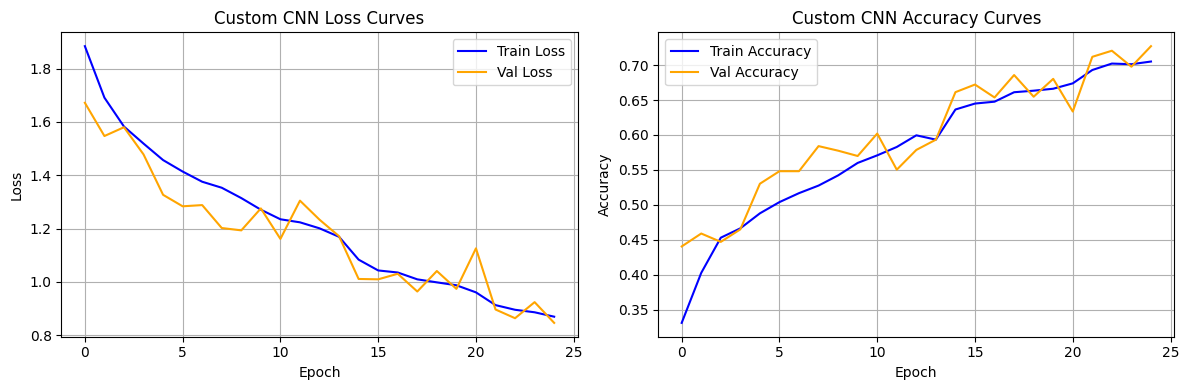

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['val_loss'], label='Val Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Custom CNN Loss Curves')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy', color='blue')
plt.plot(history['val_acc'], label='Val Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Custom CNN Accuracy Curves')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("cnn_learning_curves.png", dpi=300)
plt.show()

Cell 8: Final Unseen Test Evaluation (All Assignment Metrics)

       CUSTOM CNN FINAL TEST RESULTS         
Test Accuracy:       0.7352
Macro Precision:     0.7363
Macro Recall:        0.7198
Macro F1-Score:      0.7244
Weighted F1-Score:   0.7325
Macro ROC-AUC (OvR): 0.9554

Classification Report:

              precision    recall  f1-score   support

     battery     0.8165    0.7876    0.8018       113
  biological     0.9213    0.7810    0.8454       105
   cardboard     0.7312    0.8768    0.7974       211
     clothes     0.7898    0.8732    0.8294       284
       glass     0.7830    0.7050    0.7419       261
       metal     0.5940    0.5643    0.5788       140
       paper     0.6557    0.8000    0.7207       200
     plastic     0.7077    0.5750    0.6345       240
       shoes     0.7143    0.6912    0.7026       217
       trash     0.6491    0.5441    0.5920        68

    accuracy                         0.7352      1839
   macro avg     0.7363    0.7198    0.7244      1839
weighted avg     0.7370    0.7352    0.7325      1839



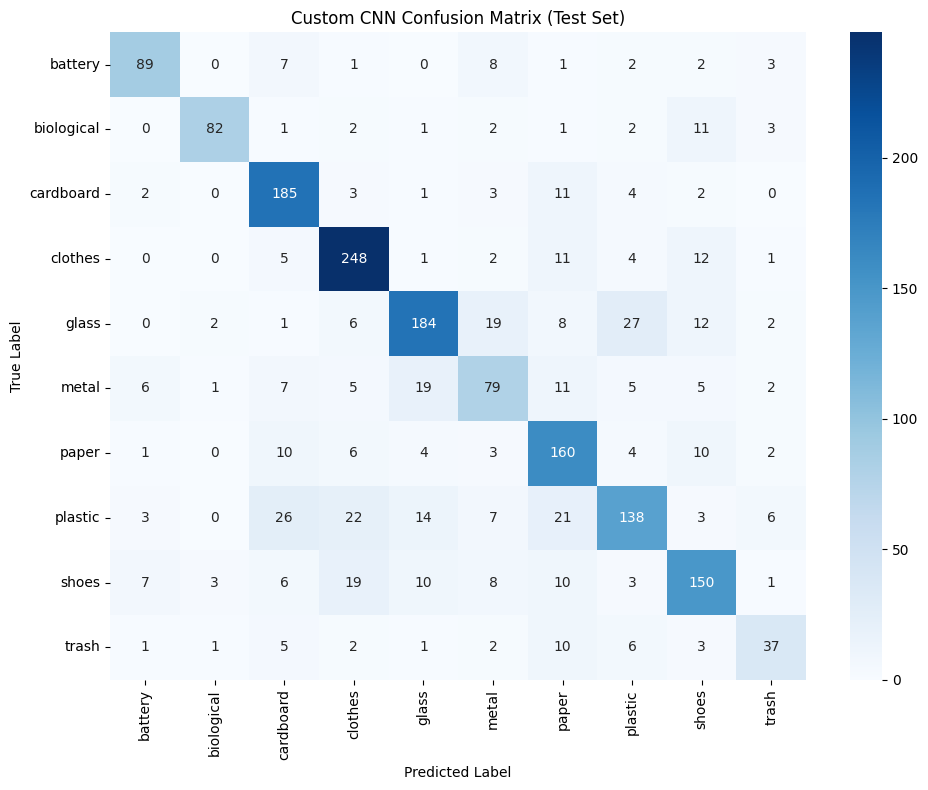

In [8]:
# Load the best saved model weights for testing
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

y_true = []
y_pred = []
y_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

class_names = [k for k, v in sorted(CLASS_MAPPING.items(), key=lambda item: item[1])]

# Calculate summary metrics
test_acc = (y_pred == y_true).mean()
macro_prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
macro_rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
roc_auc = roc_auc_score(y_true_bin, y_probs, multi_class='ovr', average='macro')

print("=" * 45)
print("       CUSTOM CNN FINAL TEST RESULTS         ")
print("=" * 45)
print(f"Test Accuracy:       {test_acc:.4f}")
print(f"Macro Precision:     {macro_prec:.4f}")
print(f"Macro Recall:        {macro_rec:.4f}")
print(f"Macro F1-Score:      {macro_f1:.4f}")
print(f"Weighted F1-Score:   {weighted_f1:.4f}")
print(f"Macro ROC-AUC (OvR): {roc_auc:.4f}")
print("=" * 45)

# Detailed Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Custom CNN Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig("cnn_confusion_matrix.png", dpi=300)
plt.show()